In [1]:
import mne
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
import scipy.signal as signal

In [2]:
from mne.time_frequency import tfr_multitaper, tfr_morlet

def compute_time_frequency_mne(raw, method='multitaper', frequencies=None, 
                              n_cycles=7, return_itc=False, verbose=False):
    """
    使用MNE计算时频表示
    
    参数:
    raw: MNE Raw对象
    method: 'multitaper' 或 'morlet'
    frequencies: 频率范围
    n_cycles: 小波变换的周期数
    return_itc: 是否返回ITC
    """
    
    # 设置频率范围
    if frequencies is None:
        frequencies = np.linspace(1, 30, 50)  # 1-30Hz, 50个频率点
    
    # 选择方法
    if method == 'multitaper':
        # 多锥形谱方法 (更平滑)
        power = tfr_multitaper(
            raw, 
            freqs=frequencies,
            n_cycles=n_cycles,
            use_fft=True,
            return_itc=return_itc,
            average=False,  # 不平均，保持试次结构
            verbose=verbose
        )
    elif method == 'morlet':
        # 小波变换方法 (更高时间分辨率)
        power = tfr_morlet(
            raw,
            freqs=frequencies,
            n_cycles=n_cycles,
            use_fft=True,
            return_itc=return_itc,
            average=False,
            output='power',
            verbose=verbose
        )
    else:
        raise ValueError("方法必须是 'multitaper' 或 'morlet'")
    
    return power

In [3]:
def create_overlapping_epochs(raw, epoch_length=10.0, overlap=2.0, sfreq=200):
    """
    创建重叠的 epochs 来分析整个数据
    
    参数:
    raw: MNE Raw 对象
    epoch_length: 每个 epoch 的长度（秒）
    overlap: epoch 之间的重叠时间（秒）
    sfreq: 采样率
    """
    # 计算需要多少个 epochs
    total_duration = raw.times[-1]
    step = epoch_length - overlap
    n_epochs = int((total_duration - epoch_length) / step) + 1
    
    # 创建事件数组
    events_list = []
    for i in range(n_epochs):
        start_sample = int(i * step * sfreq)
        if start_sample + int(epoch_length * sfreq) <= len(raw.times):
            events_list.append([start_sample, 0, 1])
    
    if len(events_list) == 0:
        # 如果数据太短，至少创建一个 epoch
        events_list = [[0, 0, 1]]
    
    events = np.array(events_list)
    epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_length,
                       baseline=None, preload=True, verbose=False)
    
    return epochs



In [4]:
def merge_overlapping_epochs_to_array(power, raw_data_length=None, epoch_length=10.0, overlap=2.0, sfreq=200):
    """
    将重叠的 epochs 合并成连续的时频矩阵
    
    参数:
    power: MNE EpochsTFR 对象 (n_epochs, n_channels, n_freqs, n_times)
    raw_data_length: 原始数据的时间点数（如果提供，将使用此值作为总长度）
    epoch_length: 每个 epoch 的长度（秒）
    overlap: epoch 之间的重叠时间（秒）
    sfreq: 采样率
    
    返回:
    numpy 数组，形状为 (n_channels, n_times_total, n_freqs)
    """
    # 获取数据维度
    data_shape = power.data.shape
    if len(data_shape) != 4:
        raise ValueError(f"期望 4 维数据，但得到 {len(data_shape)} 维: {data_shape}")
    
    n_epochs, n_channels, n_freqs, n_times_epoch = data_shape
    
    # 计算步长
    step = epoch_length - overlap
    step_samples = int(step * sfreq)
    epoch_samples = int(epoch_length * sfreq)
    
    # 确定总时间点数
    if raw_data_length is not None:
        n_times_total = raw_data_length
        total_duration = n_times_total / sfreq
    else:
        # 计算总时间点数（最后一个 epoch 的结束时间）
        total_duration = (n_epochs - 1) * step + epoch_length
        n_times_total = int(total_duration * sfreq)
    
    print(f"合并 {n_epochs} 个 epochs: 每个 {epoch_length}秒 ({epoch_samples} 点), 步长 {step}秒 ({step_samples} 点)")
    print(f"总时长: {total_duration:.2f} 秒, 总时间点: {n_times_total}")
    
    # 初始化输出数组和计数数组（用于平均重叠部分）
    merged_data = np.zeros((n_channels, n_times_total, n_freqs))
    count_data = np.zeros((n_channels, n_times_total, n_freqs))
    
    # 遍历每个 epoch
    for epoch_idx in range(n_epochs):
        epoch_start_time = epoch_idx * step
        epoch_start_sample = int(epoch_start_time * sfreq)
        
        # 将 epoch 数据插入到对应位置
        end_sample = min(epoch_start_sample + n_times_epoch, n_times_total)
        actual_length = end_sample - epoch_start_sample
        
        if actual_length > 0:
            # power.data 形状: (n_epochs, n_channels, n_freqs, n_times)
            # 提取的数据形状: (n_channels, n_freqs, actual_length)
            # 需要转换为 (n_channels, actual_length, n_freqs) 以匹配 merged_data
            epoch_data = power.data[epoch_idx, :, :, :actual_length]  # (n_channels, n_freqs, actual_length)
            epoch_data = np.transpose(epoch_data, (0, 2, 1))  # 转置为 (n_channels, actual_length, n_freqs)
            
            # 对于重叠的部分，累加值并计数
            merged_data[:, epoch_start_sample:end_sample, :] += epoch_data
            count_data[:, epoch_start_sample:end_sample, :] += 1
    
    # 对重叠部分求平均
    merged_data = np.where(count_data > 0, merged_data / count_data, 0)
    
    print(f"最终数组形状: {merged_data.shape} (应该是 (n_channels, n_times_total, n_freqs))")
    
    return merged_data



In [5]:
# 定义所有数据文件的路径和名称
data_files = {
    'anesthesia_10min': {
        'path': '/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_144124-麻醉状态10分钟/0912_250912_144124.rhs',
        'output_name': 'anesthesia_10min'
    },
    'post_anesthesia_10min': {
        'path': '/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_145403-气麻撤后30分钟记录/0912_250912_145403-气麻撤后前10分钟.rhs',
        'output_name': 'post_anesthesia_10min'
    },
    'post_anesthesia_20min': {
        'path': '/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_145403-气麻撤后30分钟记录/0912_250912_150403气麻撤后中间10分钟.rhs',
        'output_name': 'post_anesthesia_20min'
    },
    'post_anesthesia_30min': {
        'path': '/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_145403-气麻撤后30分钟记录/0912_250912_151403气麻撤后后10分钟（能够走动）.rhs',
        'output_name': 'post_anesthesia_30min'
    }
}

# 创建输出目录
output_dir = '/media/ubuntu/sda/cen/EEG_results'
os.makedirs(output_dir, exist_ok=True)

print(f"将处理 {len(data_files)} 个数据文件")
print(f"输出目录: {output_dir}")


将处理 4 个数据文件
输出目录: /media/ubuntu/sda/cen/EEG_results


In [6]:
def process_eeg_file(file_path, output_path, epoch_length=10.0, overlap=2.0, 
                     sfreq=200, freq_min=0.5, freq_max=50, 
                     frequencies=None, target_time_points=1000):
    """
    处理单个EEG文件，计算时频功率并保存
    
    参数:
    file_path: 输入文件路径
    output_path: 输出文件路径
    epoch_length: epoch长度（秒）
    overlap: epoch重叠时间（秒）
    sfreq: 目标采样率
    freq_min: 带通滤波下限
    freq_max: 带通滤波上限
    frequencies: 频率数组
    target_time_points: 降采样后的时间点数
    
    返回:
    处理后的数据数组，形状为 (n_channels, n_times, n_freqs)
    """
    print(f"\n{'='*60}")
    print(f"处理文件: {os.path.basename(file_path)}")
    print(f"{'='*60}")
    
    try:
        # 1. 读取数据
        recording_raw = se.read_intan(file_path, stream_id='0')
        recording_raw = spre.unsigned_to_signed(recording_raw)
        #recording_raw = spre.bandpass_filter(recording_raw, freq_min=freq_min, freq_max=freq_max)
        recording_raw = spre.notch_filter(recording_raw, freq=50)
        recording_recorded = spre.common_reference(recording_raw)

        # 2. 选择通道并预处理
        EEG_recording = recording_recorded.select_channels(['A-006', 'A-008'])
        EEG_recording = spre.resample(EEG_recording, sfreq)
        
        # 3. 转换为MNE格式
        EEG_data = EEG_recording.get_traces() * EEG_recording.get_channel_gains()[0]
        info = mne.create_info(ch_names=['EEG1', 'EEG2'], sfreq=sfreq, ch_types='eeg')
        raw = mne.io.RawArray(EEG_data.T, info)
        
        print(f"数据形状: {EEG_data.shape}, 时长: {raw.times[-1]:.1f} 秒")
        
        # 4. 创建epochs
        epochs_full = create_overlapping_epochs(raw, epoch_length=epoch_length, 
                                                overlap=overlap, sfreq=sfreq)
        print(f"创建了 {len(epochs_full)} 个重叠的 epochs")
        
        # 5. 计算时频功率
        if frequencies is None:
            frequencies = np.linspace(1, 30, 30)
        
        
        power_full = mne.time_frequency.tfr_multitaper(
            epochs_full, 
            freqs=frequencies, 
            n_cycles=2, 
            return_itc=False,
            average=False,
            verbose=False
        )
        print(f"Power 数据形状: {power_full.data.shape}")
        
        # 6. 合并重叠的epochs
        power_merged = merge_overlapping_epochs_to_array(
            power_full, 
            raw_data_length=EEG_data.shape[0],
            epoch_length=epoch_length, 
            overlap=overlap, 
            sfreq=sfreq
        )
        
        # 7. 降采样到目标时间点数
        n_channels, n_times, n_freqs = power_merged.shape
        compressed_data = np.zeros((n_channels, target_time_points, n_freqs))
        for ch in range(n_channels):
            for freq in range(n_freqs):
                compressed_data[ch, :, freq] = signal.resample(
                    power_merged[ch, :, freq], 
                    target_time_points
                )
        
        print(f"降采样后形状: {compressed_data.shape}")
        
        # 8. 检查并处理0值和NaN值
        # 将0值替换为1e-100，避免log转换后产生-inf或NaN
        compressed_data = np.where(compressed_data <= 0, 1e-100, compressed_data)
        compressed_data = np.where(np.isnan(compressed_data), 1e-100, compressed_data)
        compressed_data = np.where(np.isinf(compressed_data), 1e-100, compressed_data)
        
        # 检查是否有0值
        zero_count = (compressed_data <= 0).sum()
        nan_count = np.isnan(compressed_data).sum()
        inf_count = np.isinf(compressed_data).sum()
        if zero_count > 0 or nan_count > 0 or inf_count > 0:
            print(f"  警告: 发现 {zero_count} 个0值, {nan_count} 个NaN, {inf_count} 个Inf，已替换为1e-100")
        
        # 转换为dB并保存（保存2个通道）
        power_db = 10 * np.log10(compressed_data)
        
        # 再次检查转换后的NaN和-inf
        power_db = np.where(np.isnan(power_db), 10 * np.log10(1e-100), power_db)
        power_db = np.where(np.isinf(power_db), 10 * np.log10(1e-100), power_db)
        
        # 保存为 (n_channels, n_times, n_freqs) 的形状
        np.save(output_path, power_db)
        print(f"✓ 已保存到: {output_path}")
        print(f"  保存的数据形状: {power_db.shape} (2个通道)")
        
        return power_db
        
    except Exception as e:
        print(f"✗ 处理失败: {str(e)}")
        import traceback
        traceback.print_exc()
        return None


In [7]:
# 循环处理所有数据文件
results = {}
frequencies = np.linspace(0.5, 30, 60)  # 定义频率范围

for key, file_info in data_files.items():
    file_path = file_info['path']
    output_name = file_info['output_name']
    output_path = os.path.join(output_dir, f"{output_name}.npy")
    
    # 检查文件是否存在
    if not os.path.exists(file_path):
        print(f"\n⚠ 警告: 文件不存在，跳过: {file_path}")
        continue
    
    # 处理文件
    result = process_eeg_file(
        file_path=file_path,
        output_path=output_path,
        epoch_length=10.0,
        overlap=2.0,
        sfreq=200,
        freq_min=0.5,
        freq_max=50,
        frequencies=frequencies,
        target_time_points=1000
    )
    
    if result is not None:
        results[key] = result
        print(f"✓ {key} 处理完成\n")

print(f"\n{'='*60}")
print(f"处理完成！共处理 {len(results)} 个文件")
print(f"所有结果已保存到: {output_dir}")
print(f"{'='*60}")

# 显示保存的文件信息
print("\n保存的文件:")
for key in results.keys():
    output_name = data_files[key]['output_name']
    output_path = os.path.join(output_dir, f"{output_name}.npy")
    if os.path.exists(output_path):
        data = np.load(output_path)
        file_size = os.path.getsize(output_path) / (1024 * 1024)  # MB
        print(f"  - {output_name}.npy: 形状 {data.shape}, 大小 {file_size:.2f} MB")



处理文件: 0912_250912_144124.rhs
Creating RawArray with float64 data, n_channels=2, n_times=120000
    Range : 0 ... 119999 =      0.000 ...   599.995 secs
Ready.
数据形状: (120000, 2), 时长: 600.0 秒
创建了 74 个重叠的 epochs
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Power 数据形状: (74, 2, 60, 2001)
合并 74 个 epochs: 每个 10.0秒 (2000 点), 步长 8.0秒 (1600 点)
总时长: 600.00 秒, 总时间点: 120000
最终数组形状: (2, 120000, 60) (应该是 (n_channels, n_times_total, n_freqs))
降采样后形状: (2, 1000, 60)
✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/anesthesia_10min.npy
  保存的数据形状: (2, 1000, 60) (2个通道)
✓ anesthesia_10min 处理完成


处理文件: 0912_250912_145403-气麻撤后前10分钟.rhs
Creating RawArray with float64 data, n_channels=2, n_times=120000
    Range : 0 ... 119999 =      0.000 ...   599.995 secs
Ready.
数据形状: (120000, 2), 时长: 600.0 秒
创建了 74 个重叠的 epochs
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Power 数据形状: (74, 2, 60, 2001)
合并 74 个 epochs: 每个 10

In [8]:
def calculate_band_power(power_db, frequencies, band_limits):
    """
    从时频功率谱密度（dB）计算频段功率（μV²）
    
    参数:
    power_db: 时频功率数组，形状为 (n_channels, n_times, n_freqs)，单位：dB
    frequencies: 频率数组，形状为 (n_freqs,)
    band_limits: 频段定义，字典，例如 {'delta': (0.5, 4), 'theta': (4, 8), ...}
    
    返回:
    band_power: 频段功率数组，形状为 (n_channels, n_times, n_bands)，单位：μV²
    band_names: 频段名称列表
    """
    # 1. 检查并处理NaN和-inf值
    # 如果power_db中有NaN或-inf，替换为log10(1e-100)对应的dB值
    min_db_value = 10 * np.log10(1e-100)  # 约等于 -1000 dB
    power_db = np.where(np.isnan(power_db), min_db_value, power_db)
    power_db = np.where(np.isinf(power_db), min_db_value, power_db)
    
    # 2. 将dB转换回功率（μV²/Hz）
    power = 10 ** (power_db / 10)  # 从dB转换为线性功率
    
    # 3. 再次检查转换后的0值、NaN和Inf
    power = np.where(power <= 0, 1e-100, power)
    power = np.where(np.isnan(power), 1e-100, power)
    power = np.where(np.isinf(power), 1e-100, power)
    
    # 4. 计算频率分辨率（假设频率是均匀分布的）
    if len(frequencies) > 1:
        freq_resolution = frequencies[1] - frequencies[0]  # Hz
    else:
        freq_resolution = 1.0
    
    # 5. 为每个频段计算功率
    n_channels, n_times, n_freqs = power.shape
    n_bands = len(band_limits)
    
    band_power = np.zeros((n_channels, n_times, n_bands))
    band_names = list(band_limits.keys())
    
    for band_idx, (band_name, (f_min, f_max)) in enumerate(band_limits.items()):
        # 找到频段内的频率索引
        freq_mask = (frequencies >= f_min) & (frequencies <= f_max)
        
        if not freq_mask.any():
            print(f"⚠ 警告: 频段 {band_name} ({f_min}-{f_max} Hz) 没有对应的频率点")
            continue
        
        # 对频段内的功率求和（积分）
        # 功率谱密度（μV²/Hz）× 频率分辨率（Hz）= 功率（μV²）
        band_power[:, :, band_idx] = np.sum(power[:, :, freq_mask], axis=2) * freq_resolution
        
        # 显示信息
        freq_indices = np.where(freq_mask)[0]
        print(f"  {band_name:6s} ({f_min:4.1f}-{f_max:4.1f} Hz): "
              f"包含频率点 {frequencies[freq_indices[0]]:.1f}-{frequencies[freq_indices[-1]]:.1f} Hz "
              f"({len(freq_indices)} 个点)")
    
    return band_power, band_names

# 定义频段（注意：delta 0.5-4 Hz，但我们的频率从1Hz开始）
frequencies = np.linspace(1, 30, 60)  # 与处理时使用的频率一致

band_limits = {
    'delta': (0.5, 4),    # δ波（0.5-4 Hz，实际从1Hz开始）
    'theta': (4, 8),      # θ波（4-8 Hz）
    'alpha': (8, 12),     # α波（8-12 Hz）
    'beta': (12, 30)      # β波（12-30 Hz）
}

print("频段定义:")
for name, (f_min, f_max) in band_limits.items():
    print(f"  {name}: {f_min}-{f_max} Hz")
print(f"\n频率数组范围: {frequencies[0]:.1f}-{frequencies[-1]:.1f} Hz")
print(f"频率分辨率: {frequencies[1]-frequencies[0]:.2f} Hz")
print(f"总频率点数: {len(frequencies)}")


频段定义:
  delta: 0.5-4 Hz
  theta: 4-8 Hz
  alpha: 8-12 Hz
  beta: 12-30 Hz

频率数组范围: 1.0-30.0 Hz
频率分辨率: 0.49 Hz
总频率点数: 60


In [9]:
# 计算所有文件的频段功率
band_power_results = {}
frequencies = np.linspace(0.5, 30, 60)  # 与处理时使用的频率一致

print("计算各文件的频段功率...")
print("="*60)

for key, file_info in data_files.items():
    output_name = file_info['output_name']
    file_path = os.path.join(output_dir, f"{output_name}.npy")
    
    if not os.path.exists(file_path):
        print(f"\n⚠ 警告: 文件不存在，跳过: {file_path}")
        continue
    
    # 加载数据
    power_db = np.load(file_path)
    print(f"\n处理: {output_name}")
    print(f"  输入数据形状: {power_db.shape}")
    
    # 计算频段功率
    band_power, band_names = calculate_band_power(power_db, frequencies, band_limits)
    
    # 保存结果
    output_path_band = os.path.join(output_dir, f"{output_name}_band_power.npy")
    np.save(output_path_band, band_power)
    
    band_power_results[key] = band_power
    
    print(f"  ✓ 频段功率形状: {band_power.shape} (n_channels, n_times, n_bands)")
    print(f"  ✓ 已保存到: {output_path_band}")
    
    # 显示每个频段的功率范围
    print(f"  各频段功率范围 (μV²):")
    for i, band_name in enumerate(band_names):
        band_data = band_power[:, :, i]
        print(f"    {band_name:6s}: {band_data.min():.2e} 到 {band_data.max():.2e} μV² "
              f"(平均: {band_data.mean():.2e} μV²)")

print(f"\n{'='*60}")
print(f"所有频段功率计算完成！")
print(f"{'='*60}")


计算各文件的频段功率...

处理: anesthesia_10min
  输入数据形状: (2, 1000, 60)
  delta  ( 0.5- 4.0 Hz): 包含频率点 0.5-4.0 Hz (8 个点)
  theta  ( 4.0- 8.0 Hz): 包含频率点 4.0-8.0 Hz (9 个点)
  alpha  ( 8.0-12.0 Hz): 包含频率点 8.0-12.0 Hz (9 个点)
  beta   (12.0-30.0 Hz): 包含频率点 12.0-30.0 Hz (37 个点)
  ✓ 频段功率形状: (2, 1000, 4) (n_channels, n_times, n_bands)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/anesthesia_10min_band_power.npy
  各频段功率范围 (μV²):
    delta : 4.00e-100 到 4.34e+06 μV² (平均: 4.84e+05 μV²)
    theta : 4.50e-100 到 7.83e+05 μV² (平均: 1.22e+05 μV²)
    alpha : 4.50e-100 到 3.84e+05 μV² (平均: 5.57e+04 μV²)
    beta  : 1.85e-99 到 5.82e+05 μV² (平均: 7.59e+04 μV²)

处理: post_anesthesia_10min
  输入数据形状: (2, 1000, 60)
  delta  ( 0.5- 4.0 Hz): 包含频率点 0.5-4.0 Hz (8 个点)
  theta  ( 4.0- 8.0 Hz): 包含频率点 4.0-8.0 Hz (9 个点)
  alpha  ( 8.0-12.0 Hz): 包含频率点 8.0-12.0 Hz (9 个点)
  beta   (12.0-30.0 Hz): 包含频率点 12.0-30.0 Hz (37 个点)
  ✓ 频段功率形状: (2, 1000, 4) (n_channels, n_times, n_bands)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/post_anesthesia_1

In [10]:
def calculate_normalized_power(band_power, band_names):
    """
    计算各频段的归一化功率（百分比）
    
    参数:
    band_power: 频段功率数组，形状为 (n_channels, n_times, n_bands)，单位：μV²
    band_names: 频段名称列表
    
    返回:
    normalized_power: 归一化功率数组，形状为 (n_channels, n_times, n_bands)，单位：%
    """
    # 计算总功率（所有频段之和）
    total_power = np.sum(band_power, axis=2, keepdims=True)  # (n_channels, n_times, 1)
    
    # 避免除以0
    total_power = np.where(total_power == 0, 1e-10, total_power)
    
    # 计算归一化功率（百分比）
    normalized_power = (band_power / total_power) * 100  # 转换为百分比
    
    return normalized_power

def calculate_full_band_normalized_power(power_db, frequencies, freq_range=(0.5, 30)):
    """
    计算指定频率范围内的归一化功率（百分比）
    
    参数:
    power_db: 时频功率数组，形状为 (n_channels, n_times, n_freqs)，单位：dB
    frequencies: 频率数组
    freq_range: 频率范围 (f_min, f_max)
    
    返回:
    normalized_power: 归一化功率数组，形状为 (n_channels, n_times, n_freqs)，单位：%
    """
    # 1. 检查并处理NaN和-inf值
    # 如果power_db中有NaN或-inf，替换为log10(1e-100)对应的dB值
    min_db_value = 10 * np.log10(1e-100)  # 约等于 -1000 dB
    power_db = np.where(np.isnan(power_db), min_db_value, power_db)
    power_db = np.where(np.isinf(power_db), min_db_value, power_db)
    
    # 2. 将dB转换回功率（μV²/Hz）
    power = 10 ** (power_db / 10)
    
    # 3. 再次检查转换后的0值、NaN和Inf
    power = np.where(power <= 0, 1e-100, power)
    power = np.where(np.isnan(power), 1e-100, power)
    power = np.where(np.isinf(power), 1e-100, power)
    
    # 4. 计算频率分辨率
    if len(frequencies) > 1:
        freq_resolution = frequencies[1] - frequencies[0]
    else:
        freq_resolution = 1.0
    
    # 5. 找到指定频率范围内的频率点
    f_min, f_max = freq_range
    freq_mask = (frequencies >= f_min) & (frequencies <= f_max)
    
    if not freq_mask.any():
        print(f"⚠ 警告: 频率范围 {freq_range} 没有对应的频率点")
        return None
    
    # 6. 计算指定频率范围内的总功率（每个时间点的总功率）
    total_power_in_range = np.sum(power[:, :, freq_mask], axis=2, keepdims=True) * freq_resolution
    total_power_in_range = np.where(total_power_in_range == 0, 1e-100, total_power_in_range)
    
    # 7. 计算归一化功率（每个频率点的功率 / 该时间点的总功率）
    normalized_power = (power * freq_resolution / total_power_in_range) * 100
    
    return normalized_power

print("归一化功率计算函数已定义")


归一化功率计算函数已定义


In [11]:
# 计算每个数据段的频段归一化功率（百分比）
frequencies = np.linspace(0.5, 30, 60)  # 与处理时使用的频率一致

print("="*60)
print("计算各数据段的频段归一化功率（百分比）")
print("="*60)

normalized_band_power_results = {}

for key, file_info in data_files.items():
    output_name = file_info['output_name']
    band_power_path = os.path.join(output_dir, f"{output_name}_band_power.npy")
    
    if not os.path.exists(band_power_path):
        print(f"\n⚠ 警告: 文件不存在，跳过: {band_power_path}")
        continue
    
    # 加载频段功率数据
    band_power = np.load(band_power_path)
    print(f"\n处理: {output_name}")
    print(f"  输入数据形状: {band_power.shape}")
    
    # 计算归一化功率
    normalized_power = calculate_normalized_power(band_power, band_names)
    normalized_band_power_results[key] = normalized_power
    
    # 保存结果
    output_path_norm = os.path.join(output_dir, f"{output_name}_normalized_band_power.npy")
    np.save(output_path_norm, normalized_power)
    
    print(f"  ✓ 归一化功率形状: {normalized_power.shape}")
    print(f"  ✓ 已保存到: {output_path_norm}")
    
    # 显示每个频段的归一化功率范围
    print(f"  各频段归一化功率范围 (%):")
    for i, band_name in enumerate(band_names):
        band_data = normalized_power[:, :, i]
        print(f"    {band_name:6s}: {band_data.min():.2f}% 到 {band_data.max():.2f}% "
              f"(平均: {band_data.mean():.2f}%)")
    
    # 验证：所有频段的归一化功率之和应该接近100%
    total_percent = np.sum(normalized_power, axis=2)
    print(f"  验证: 所有频段功率之和 = {total_percent.mean():.2f}% (应该接近100%)")

print(f"\n{'='*60}")
print("频段归一化功率计算完成！")
print(f"{'='*60}")


计算各数据段的频段归一化功率（百分比）

处理: anesthesia_10min
  输入数据形状: (2, 1000, 4)
  ✓ 归一化功率形状: (2, 1000, 4)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/anesthesia_10min_normalized_band_power.npy
  各频段归一化功率范围 (%):
    delta : 12.70% 到 100.00% (平均: 66.11%)
    theta : 0.00% 到 32.02% (平均: 16.14%)
    alpha : 0.00% 到 19.54% (平均: 7.43%)
    beta  : 0.00% 到 58.73% (平均: 10.32%)
  验证: 所有频段功率之和 = 100.00% (应该接近100%)

处理: post_anesthesia_10min
  输入数据形状: (2, 1000, 4)
  ✓ 归一化功率形状: (2, 1000, 4)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/post_anesthesia_10min_normalized_band_power.npy
  各频段归一化功率范围 (%):
    delta : 0.58% 到 100.00% (平均: 70.48%)
    theta : 0.00% 到 31.12% (平均: 14.38%)
    alpha : 0.00% 到 24.81% (平均: 6.44%)
    beta  : 0.00% 到 47.41% (平均: 8.70%)
  验证: 所有频段功率之和 = 100.00% (应该接近100%)

处理: post_anesthesia_20min
  输入数据形状: (2, 1000, 4)
  ✓ 归一化功率形状: (2, 1000, 4)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/post_anesthesia_20min_normalized_band_power.npy
  各频段归一化功率范围 (%):
    delta : 0.00% 到 100.00% (平均: 77.55%)

In [12]:
# 计算每个数据在0.5-30Hz范围内的归一化功率（百分比）
print("\n" + "="*60)
print("计算各数据在0.5-30Hz范围内的归一化功率（百分比）")
print("="*60)

normalized_full_band_results = {}

for key, file_info in data_files.items():
    output_name = file_info['output_name']
    power_db_path = os.path.join(output_dir, f"{output_name}.npy")
    
    if not os.path.exists(power_db_path):
        print(f"\n⚠ 警告: 文件不存在，跳过: {power_db_path}")
        continue
    
    # 加载时频功率数据
    power_db = np.load(power_db_path)
    print(f"\n处理: {output_name}")
    print(f"  输入数据形状: {power_db.shape}")
    
    # 计算0.5-30Hz范围内的归一化功率
    normalized_full = calculate_full_band_normalized_power(
        power_db, 
        frequencies, 
        freq_range=(0.5, 30)
    )
    
    if normalized_full is not None:
        normalized_full_band_results[key] = normalized_full
        
        # 保存结果
        output_path_full = os.path.join(output_dir, f"{output_name}_normalized_0.5-30Hz.npy")
        np.save(output_path_full, normalized_full)
        
        print(f"  ✓ 归一化功率形状: {normalized_full.shape}")
        print(f"  ✓ 已保存到: {output_path_full}")
        
        # 显示统计信息
        print(f"  归一化功率范围: {normalized_full.min():.2f}% 到 {normalized_full.max():.2f}%")
        print(f"  平均归一化功率: {normalized_full.mean():.2f}%")
        
        # 验证：每个时间点的所有频率归一化功率之和应该接近100%
        total_percent_per_time = np.sum(normalized_full, axis=2)  # (n_channels, n_times)
        print(f"  验证: 每个时间点的总功率 = {total_percent_per_time.mean():.2f}% (应该接近100%)")
        print(f"        范围: {total_percent_per_time.min():.2f}% 到 {total_percent_per_time.max():.2f}%")

print(f"\n{'='*60}")
print("0.5-30Hz归一化功率计算完成！")
print(f"{'='*60}")



计算各数据在0.5-30Hz范围内的归一化功率（百分比）

处理: anesthesia_10min
  输入数据形状: (2, 1000, 60)
  ✓ 归一化功率形状: (2, 1000, 60)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/anesthesia_10min_normalized_0.5-30Hz.npy
  归一化功率范围: 0.00% 到 100.00%
  平均归一化功率: 1.67%
  验证: 每个时间点的总功率 = 100.00% (应该接近100%)
        范围: 100.00% 到 100.00%

处理: post_anesthesia_10min
  输入数据形状: (2, 1000, 60)
  ✓ 归一化功率形状: (2, 1000, 60)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/post_anesthesia_10min_normalized_0.5-30Hz.npy
  归一化功率范围: 0.00% 到 100.00%
  平均归一化功率: 1.67%
  验证: 每个时间点的总功率 = 100.00% (应该接近100%)
        范围: 100.00% 到 100.00%

处理: post_anesthesia_20min
  输入数据形状: (2, 1000, 60)
  ✓ 归一化功率形状: (2, 1000, 60)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/post_anesthesia_20min_normalized_0.5-30Hz.npy
  归一化功率范围: 0.00% 到 100.00%
  平均归一化功率: 1.67%
  验证: 每个时间点的总功率 = 100.00% (应该接近100%)
        范围: 100.00% 到 100.00%

处理: post_anesthesia_30min
  输入数据形状: (2, 1000, 60)
  ✓ 归一化功率形状: (2, 1000, 60)
  ✓ 已保存到: /media/ubuntu/sda/cen/EEG_results/post_anesthesia_30min

In [13]:
# 加载所有数据
print("加载数据...")
data_dict = {}
band_power_dict = {}
normalized_band_power_dict = {}
normalized_full_band_dict = {}

for key, file_info in data_files.items():
    output_name = file_info['output_name']
    
    # 加载时频功率数据（dB）
    power_path = os.path.join(output_dir, f"{output_name}.npy")
    if os.path.exists(power_path):
        data_dict[key] = np.load(power_path)
        print(f"  ✓ 加载 {output_name}.npy: {data_dict[key].shape}")
    
    # 加载频段功率数据
    band_power_path = os.path.join(output_dir, f"{output_name}_band_power.npy")
    if os.path.exists(band_power_path):
        band_power_dict[key] = np.load(band_power_path)
        print(f"  ✓ 加载 {output_name}_band_power.npy: {band_power_dict[key].shape}")
    
    # 加载频段归一化功率数据
    norm_band_path = os.path.join(output_dir, f"{output_name}_normalized_band_power.npy")
    if os.path.exists(norm_band_path):
        normalized_band_power_dict[key] = np.load(norm_band_path)
        print(f"  ✓ 加载 {output_name}_normalized_band_power.npy: {normalized_band_power_dict[key].shape}")
    
    # 加载0.5-30Hz归一化功率数据
    norm_full_path = os.path.join(output_dir, f"{output_name}_normalized_0.5-30Hz.npy")
    if os.path.exists(norm_full_path):
        normalized_full_band_dict[key] = np.load(norm_full_path)
        print(f"  ✓ 加载 {output_name}_normalized_0.5-30Hz.npy: {normalized_full_band_dict[key].shape}")

print(f"\n数据加载完成！")
print(f"  时频功率数据: {len(data_dict)} 个文件")
print(f"  频段功率数据: {len(band_power_dict)} 个文件")
print(f"  频段归一化功率数据: {len(normalized_band_power_dict)} 个文件")
print(f"  全频段归一化功率数据: {len(normalized_full_band_dict)} 个文件")


加载数据...
  ✓ 加载 anesthesia_10min.npy: (2, 1000, 60)
  ✓ 加载 anesthesia_10min_band_power.npy: (2, 1000, 4)
  ✓ 加载 anesthesia_10min_normalized_band_power.npy: (2, 1000, 4)
  ✓ 加载 anesthesia_10min_normalized_0.5-30Hz.npy: (2, 1000, 60)
  ✓ 加载 post_anesthesia_10min.npy: (2, 1000, 60)
  ✓ 加载 post_anesthesia_10min_band_power.npy: (2, 1000, 4)
  ✓ 加载 post_anesthesia_10min_normalized_band_power.npy: (2, 1000, 4)
  ✓ 加载 post_anesthesia_10min_normalized_0.5-30Hz.npy: (2, 1000, 60)
  ✓ 加载 post_anesthesia_20min.npy: (2, 1000, 60)
  ✓ 加载 post_anesthesia_20min_band_power.npy: (2, 1000, 4)
  ✓ 加载 post_anesthesia_20min_normalized_band_power.npy: (2, 1000, 4)
  ✓ 加载 post_anesthesia_20min_normalized_0.5-30Hz.npy: (2, 1000, 60)
  ✓ 加载 post_anesthesia_30min.npy: (2, 1000, 60)
  ✓ 加载 post_anesthesia_30min_band_power.npy: (2, 1000, 4)
  ✓ 加载 post_anesthesia_30min_normalized_band_power.npy: (2, 1000, 4)
  ✓ 加载 post_anesthesia_30min_normalized_0.5-30Hz.npy: (2, 1000, 60)

数据加载完成！
  时频功率数据: 4 个文件
  频段功率数据: 4 个文件

In [14]:
# 定义绘图参数
frequencies = np.linspace(0.5, 30, 60)
band_names = ['delta', 'theta', 'alpha', 'beta']
file_order = ['anesthesia_10min', 'post_anesthesia_10min', 'post_anesthesia_20min', 'post_anesthesia_30min']
file_labels = ['Anesthesia 10min', 'Post-anesthesia 10min', 'Post-anesthesia 20min', 'Post-anesthesia 30min']

# 创建输出目录
plot_output_dir = os.path.join(output_dir, 'plots')
os.makedirs(plot_output_dir, exist_ok=True)
print(f"图表将保存到: {plot_output_dir}")

# 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 使用默认字体
plt.rcParams['axes.unicode_minus'] = False


图表将保存到: /media/ubuntu/sda/cen/EEG_results/plots


In [15]:
# 图1: Heatmap - 拼接4个阶段的log power数据
print("\n" + "="*60)
print("绘制图1: Heatmap - 拼接的log power数据")
print("="*60)

# 拼接数据（选择通道1）
concatenated_power = []
time_boundaries = [0]  # 记录时间分割点

for i, key in enumerate(file_order):
    if key in data_dict:
        # 选择通道1（索引0）
        power_data = data_dict[key][0, :, :]  # (n_times, n_freqs)
        concatenated_power.append(power_data)
        time_boundaries.append(time_boundaries[-1] + power_data.shape[0])
        print(f"  {file_labels[i]}: {power_data.shape}")

if concatenated_power:
    # 拼接所有数据
    full_power = np.concatenate(concatenated_power, axis=0)  # (total_times, n_freqs)
    print(f"  拼接后形状: {full_power.shape}")
    
    # 绘制热图
    fig, ax = plt.subplots(figsize=(20, 3))
    
    # 计算colormap范围：-20到最大值
    vmin = 0
    vmax = np.nanmax(full_power)
    print(f"  Colormap范围: {vmin} 到 {vmax:.2f} dB")
    
    # 绘制热图
    im = ax.imshow(full_power.T, aspect='auto', origin='lower', 
                   cmap='coolwarm', interpolation='nearest',
                   vmin=vmin, vmax=vmax)
    
    # 设置坐标轴
    ax.set_xlabel('Time (samples)', fontsize=12)
    ax.set_ylabel('Frequency (Hz)', fontsize=12)
    ax.set_title('Log Power Spectrogram (Channel 1 - EEG1)', fontsize=14, fontweight='bold')
    
    freq_indices = np.linspace(0, len(frequencies)-1, 10).astype(int)
    ax.set_yticks([])
    ax.set_xticks([])
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Log Power (dB)', fontsize=12)
    
    # 在时间分割处绘制竖线
    for i, boundary in enumerate(time_boundaries[1:-1], 1):  # 跳过第一个和最后一个
        ax.axvline(x=boundary, color='black', linestyle='--', linewidth=2, alpha=0.7)

    
    plt.tight_layout()
    
    # 保存为PDF
    output_path = os.path.join(plot_output_dir, '1_heatmap_log_power.pdf')
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    print(f"  ✓ 已保存: {output_path}")
    plt.close()
else:
    print("  ⚠ 警告: 没有可用的数据")



绘制图1: Heatmap - 拼接的log power数据
  Anesthesia 10min: (1000, 60)
  Post-anesthesia 10min: (1000, 60)
  Post-anesthesia 20min: (1000, 60)
  Post-anesthesia 30min: (1000, 60)
  拼接后形状: (4000, 60)
  Colormap范围: 0 到 82.64 dB
  ✓ 已保存: /media/ubuntu/sda/cen/EEG_results/plots/1_heatmap_log_power.pdf


In [16]:
# 图2: Lineplot - 各波段的功率（拼接后）
print("\n" + "="*60)
print("绘制图2: Lineplot - 各波段功率")
print("="*60)

# 拼接频段功率数据（选择通道1）
concatenated_band_power = []
time_boundaries_band = [0]

for i, key in enumerate(file_order):
    if key in band_power_dict:
        # 选择通道1（索引0）
        band_data = band_power_dict[key][0, :, :]  # (n_times, n_bands)
        concatenated_band_power.append(band_data)
        time_boundaries_band.append(time_boundaries_band[-1] + band_data.shape[0])
        print(f"  {file_labels[i]}: {band_data.shape}")

if concatenated_band_power:
    # 拼接所有数据
    full_band_power = np.concatenate(concatenated_band_power, axis=0)  # (total_times, n_bands)
    print(f"  拼接后形状: {full_band_power.shape}")
    
    # 创建时间轴
    time_axis = np.arange(full_band_power.shape[0])
    
    # 绘制线图
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # 为每个波段绘制一条线
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # 不同颜色
    for i, band_name in enumerate(band_names):
        ax.plot(time_axis, full_band_power[:, i], 
               label=band_name.upper(), linewidth=2, color=colors[i], alpha=0.8)
    
    # 在时间分割处绘制竖线
    for i, boundary in enumerate(time_boundaries_band[1:-1], 1):
        ax.axvline(x=boundary, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
        ax.text(boundary, ax.get_ylim()[1]*0.95, file_labels[i-1], 
                rotation=90, verticalalignment='top', horizontalalignment='right',
                fontsize=9, color='gray')
    
    ax.set_xlabel('Time (samples)', fontsize=12)
    ax.set_ylabel('Band Power (μV²)', fontsize=12)
    ax.set_title('Band Power Over Time (Channel 1 - EEG1)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 保存为PDF
    output_path = os.path.join(plot_output_dir, '2_lineplot_band_power.pdf')
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    print(f"  ✓ 已保存: {output_path}")
    plt.close()
else:
    print("  ⚠ 警告: 没有可用的数据")



绘制图2: Lineplot - 各波段功率
  Anesthesia 10min: (1000, 4)
  Post-anesthesia 10min: (1000, 4)
  Post-anesthesia 20min: (1000, 4)
  Post-anesthesia 30min: (1000, 4)
  拼接后形状: (4000, 4)
  ✓ 已保存: /media/ubuntu/sda/cen/EEG_results/plots/2_lineplot_band_power.pdf


In [17]:
# 图3: Normalize power和Hz的lineplot（四段数据分别绘制一条线）
print("\n" + "="*60)
print("绘制图3: Normalize power vs Frequency (Hz)")
print("="*60)

if normalized_full_band_dict:
    # 计算每个数据段的平均归一化功率（对时间维度求平均）
    mean_normalized_power = {}
    
    for key in file_order:
        if key in normalized_full_band_dict:
            # 选择通道1，对时间维度求平均
            mean_power = np.mean(normalized_full_band_dict[key][0, :, :], axis=0)  # (n_freqs,)
            mean_normalized_power[key] = mean_power
            print(f"  {key}: 平均归一化功率形状 {mean_power.shape}")
    
    if mean_normalized_power:
        # 绘制线图
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # 为每个数据段绘制一条线
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        for i, key in enumerate(file_order):
            if key in mean_normalized_power:
                ax.plot(frequencies, mean_normalized_power[key], 
                       label=file_labels[i], linewidth=2.5, color=colors[i], alpha=0.8, marker='o', markersize=3)
        
        ax.set_xlabel('Frequency (Hz)', fontsize=12)
        ax.set_ylabel('Normalized Power (%)', fontsize=12)
        ax.set_title('Normalized Power vs Frequency (Channel 1 - EEG1)', fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([frequencies[0], frequencies[-1]])
        
        plt.tight_layout()
        
        # 保存为PDF
        output_path = os.path.join(plot_output_dir, '3_lineplot_normalized_power_vs_frequency.pdf')
        plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
        print(f"  ✓ 已保存: {output_path}")
        plt.close()
    else:
        print("  ⚠ 警告: 没有可用的平均归一化功率数据")
else:
    print("  ⚠ 警告: 没有可用的归一化功率数据")



绘制图3: Normalize power vs Frequency (Hz)
  anesthesia_10min: 平均归一化功率形状 (60,)
  post_anesthesia_10min: 平均归一化功率形状 (60,)
  post_anesthesia_20min: 平均归一化功率形状 (60,)
  post_anesthesia_30min: 平均归一化功率形状 (60,)
  ✓ 已保存: /media/ubuntu/sda/cen/EEG_results/plots/3_lineplot_normalized_power_vs_frequency.pdf


In [18]:
# 图4: Normalize power和frequency band的柱状图
print("\n" + "="*60)
print("绘制图4: Normalize power vs Frequency Band")
print("="*60)

if normalized_band_power_dict:
    # 计算每个数据段每个波段的平均归一化功率（对时间维度求平均）
    mean_band_normalized = {}
    
    for key in file_order:
        if key in normalized_band_power_dict:
            # 选择通道1，对时间维度求平均
            mean_power = np.mean(normalized_band_power_dict[key][0, :, :], axis=0)  # (n_bands,)
            mean_band_normalized[key] = mean_power
            print(f"  {key}: 平均归一化功率形状 {mean_power.shape}")
    
    if mean_band_normalized:
        # 准备数据用于绘图
        x = np.arange(len(band_names))  # 频率波段位置
        width = 0.2  # 柱状图宽度
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        
        # 绘制柱状图
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # 为每个数据段绘制柱状图
        for i, key in enumerate(file_order):
            if key in mean_band_normalized:
                offset = (i - 1.5) * width  # 居中排列
                bars = ax.bar(x + offset, mean_band_normalized[key], 
                             width, label=file_labels[i], color=colors[i], alpha=0.8)
                
                # 在柱状图上添加数值标签
                for j, bar in enumerate(bars):
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
        
        ax.set_xlabel('Frequency Band', fontsize=12)
        ax.set_ylabel('Normalized Power (%)', fontsize=12)
        ax.set_title('Normalized Power by Frequency Band (Channel 1 - EEG1)', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([b.upper() for b in band_names])
        ax.legend(loc='best', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, max([np.max(mean_band_normalized[k]) for k in mean_band_normalized.keys()]) * 1.2])
        
        plt.tight_layout()
        
        # 保存为PDF
        output_path = os.path.join(plot_output_dir, '4_barplot_normalized_power_vs_band.pdf')
        plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
        print(f"  ✓ 已保存: {output_path}")
        plt.close()
    else:
        print("  ⚠ 警告: 没有可用的平均归一化功率数据")
else:
    print("  ⚠ 警告: 没有可用的归一化功率数据")

print(f"\n{'='*60}")
print("所有图表绘制完成！")
print(f"{'='*60}")
print(f"\n所有PDF文件已保存到: {plot_output_dir}")



绘制图4: Normalize power vs Frequency Band
  anesthesia_10min: 平均归一化功率形状 (4,)
  post_anesthesia_10min: 平均归一化功率形状 (4,)
  post_anesthesia_20min: 平均归一化功率形状 (4,)
  post_anesthesia_30min: 平均归一化功率形状 (4,)
  ✓ 已保存: /media/ubuntu/sda/cen/EEG_results/plots/4_barplot_normalized_power_vs_band.pdf

所有图表绘制完成！

所有PDF文件已保存到: /media/ubuntu/sda/cen/EEG_results/plots


In [19]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
recording_raw = se.read_intan('/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_144124-麻醉状态10分钟', stream_id='0')


In [ ]:
recording_list = []
for file in data_files.keys():
    recording_list.append(se.read_intan(data_files[file]['path'], stream_id='0'))
    print(file)

recording_raw = si.concatenate_recordings(recording_list)

anesthesia_10min
post_anesthesia_10min
post_anesthesia_20min
post_anesthesia_30min


In [ ]:
recording_raw = spre.unsigned_to_signed(recording_raw)

#recording_comm = recording_raw.select_channels(['A-002', 'A-004', 'A-006', 'A-008'])
#recording_comm = spre.common_reference(recording_raw)
EMG_recording = recording_raw.select_channels(['A-002', 'A-004'])
EMG_recording = spre.bandpass_filter(EMG_recording, freq_min=10, freq_max=500)
EMG_recording = spre.notch_filter(EMG_recording, freq=50)
EMG_recording = spre.resample(EMG_recording, 200)

In [ ]:
EMG_data = EMG_recording.get_traces()

In [ ]:
EMG_data.shape

(480000, 2)

<Axes: >

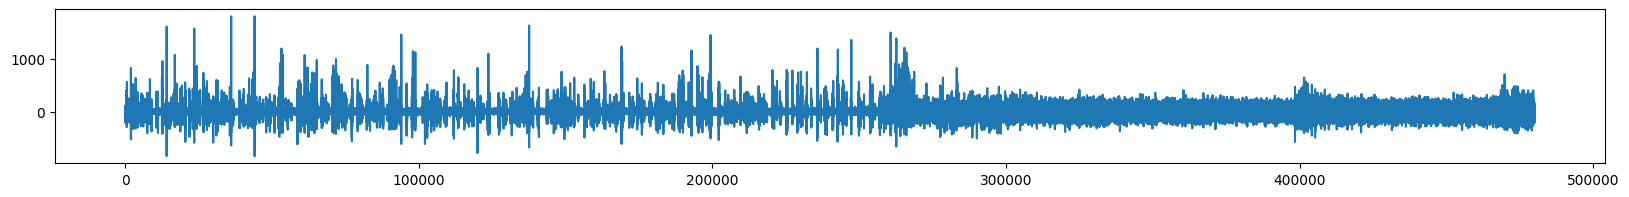

In [ ]:
plt.figure(figsize=(20, 2))
sns.lineplot(EMG_data[:, 0])